In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU available via tf.config:", tf.config.list_physical_devices('GPU'))

from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

2025-06-30 07:50:22.998908: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-30 07:50:23.083073: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-30 07:50:23.103178: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-30 07:50:23.209083: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-30 07:50:24.875533: W tensorflow/comp

TensorFlow version: 2.17.0
Built with CUDA: True
GPU available via tf.config: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 14815464021818415482
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 15502344192
locality {
  bus_id: 1
  links {
  }
}
incarnation: 10393111319106428542
physical_device_desc: "device: 0, name: Tesla V100-PCIE-16GB, pci bus id: 0000:5e:00.0, compute capability: 7.0"
xla_global_id: 416903419
]


2025-06-30 07:50:27.214162: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /device:GPU:0 with 14784 MB memory:  -> device: 0, name: Tesla V100-PCIE-16GB, pci bus id: 0000:5e:00.0, compute capability: 7.0


## Combined script all stocks

In [34]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from imblearn.over_sampling import BorderlineSMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from collections import Counter
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

def focal_loss(gamma=2.0, alpha=[2.0, 1.0, 0.5, 1.0, 2.0]):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_onehot = tf.one_hot(y_true, depth=5)
        cross_entropy = tf.keras.losses.categorical_crossentropy(y_true_onehot, y_pred)
        probs = tf.reduce_sum(y_pred * y_true_onehot, axis=-1)
        alpha_tensor = tf.constant(alpha, dtype=tf.float32)
        weights = tf.reduce_sum(alpha_tensor * y_true_onehot, axis=-1)
        focal = weights * tf.pow(1. - probs, gamma) * cross_entropy
        return focal
    return loss

early_stop = EarlyStopping(
    monitor='val_loss',     # or 'val_accuracy'
    patience=15,            # number of epochs with no improvement after which training will be stopped
    restore_best_weights=True,
    verbose=1
)

# GPU memory handling
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
tf.keras.backend.clear_session()
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# === Parameters ===
time_steps = 40
forward_days = 5
classes = 5
folder_path = "stocks"  # Pfad zum Ordner mit CSVs

# === Features ===
features = ['Open', 'High', 'Low', 'Close', 'Volume', 
            'MA10', 'MA20', 'MA50', 'MACD_ml', 'MACD_his', 
            'RSI14', 'OBV', 'ATR', 'StochasticMomentum']

X_all, y_all = [], []

# === Hilfsfunktion: Feature-Engineering ===
def process_stock(df):
    df = df.sort_values('Date').reset_index(drop=True)
    df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = df['EMA12'] - df['EMA26']
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_his'] = df['MACD'] - df['MACD_signal']
    df.dropna(inplace=True)
    df = df.reset_index(drop=True)

    # Füge Dummy-Spalten hinzu, wenn du sie brauchst
    for f in features:
        if f not in df.columns:
            df[f] = 0.0

    # Skaliere nur die Features
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[features])

    X, y = [], []
    for i in range(len(scaled) - time_steps - forward_days):
        X.append(scaled[i:i+time_steps])
        curr = df['Close'].iloc[i+time_steps-1]
        future = df['Close'].iloc[i+time_steps+forward_days-1]
        pct = (future - curr) / curr * 100
        if pct <= -2:
            label = 0
        elif -2 < pct <= -0.5:
            label = 1
        elif -0.5 < pct < 0.5:
            label = 2
        elif 0.5 <= pct < 2:
            label = 3
        else:
            label = 4
        y.append(label)

    return np.array(X), np.array(y)

# === Alle Dateien im Ordner verarbeiten ===
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        try:
            df = pd.read_csv(os.path.join(folder_path, file), parse_dates=['Date'])
            X_part, y_part = process_stock(df)
            if len(X_part) > 0:
                X_all.append(X_part)
                y_all.append(y_part)
                print(f"{file}: {len(X_part)} samples")
        except Exception as e:
            print(f"Fehler bei Datei {file}: {e}")

# === Kombinieren ===
X = np.vstack(X_all)
y = np.hstack(y_all)

# === Resampling ===
X_reshaped = X.reshape(X.shape[0], -1)
X_resampled, y_resampled = BorderlineSMOTE(kind='borderline-2').fit_resample(X_reshaped, y)
X_resampled = X_resampled.reshape(-1, time_steps, len(features))

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.1, random_state=42)

# === Modell ===
def Create_LSTM_Model(units=64, drop_out=0.4, lr=1e-3):
    model = Sequential()
    model.add(LSTM(units=units, input_shape=(time_steps, len(features)), return_sequences=True))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(LSTM(units=units))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(Dense(units=units, activation='tanh'))
    model.add(Dropout(drop_out))
    model.add(BatchNormalization())
    model.add(Dense(units=5, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

class_weights = {
    0: 2.0,  # Big Drop
    1: 1.0,  # Small Drop
    2: 0.3,  # Neutral (weniger wichtig)
    3: 1.0,  # Small Rise
    4: 2.0   # Big Rise
}

# === Training ===
model = Create_LSTM_Model()

history = model.fit(
    X_train, y_train,
    epochs=400,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=0
)

# === Evaluation ===
model.evaluate(X_test, y_test)
y_pred = np.argmax(model.predict(X_test), axis=1)
conf_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)

print("Per-class accuracy:")
for i in np.unique(y_test):
    if i < conf_mat.shape[0]:
        acc = 100 * conf_mat[i, i] / sum(conf_mat[i]) if sum(conf_mat[i]) > 0 else 0
        print(f"Label {i} accuracy: {acc:.1f}%")


Num GPUs Available: 1
NVDA.csv: 104 samples
META.csv: 104 samples
AMZN.csv: 104 samples
HOOD.csv: 104 samples
TSLA.csv: 104 samples
GOOGL.csv: 104 samples
PLTR.csv: 104 samples
AAPL.csv: 104 samples
UBER.csv: 104 samples
MSFT.csv: 104 samples


/opt/conda/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 91: early stopping
Restoring model weights from the end of the best epoch: 76.
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7433 - loss: 0.8095 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Confusion Matrix:
 [[30  6  0  1  0]
 [ 2 39  0  1  3]
 [ 0 11 22 13  4]
 [ 1  7  1 32  4]
 [ 0  1  0  3 37]]
Per-class accuracy:
Label 0 accuracy: 81.1%
Label 1 accuracy: 86.7%
Label 2 accuracy: 44.0%
Label 3 accuracy: 71.1%
Label 4 accuracy: 90.2%


#### PLOTS

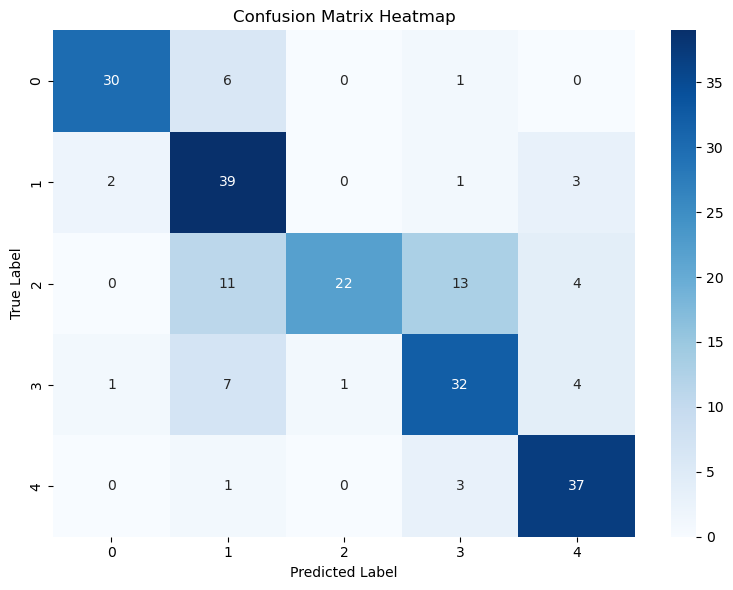

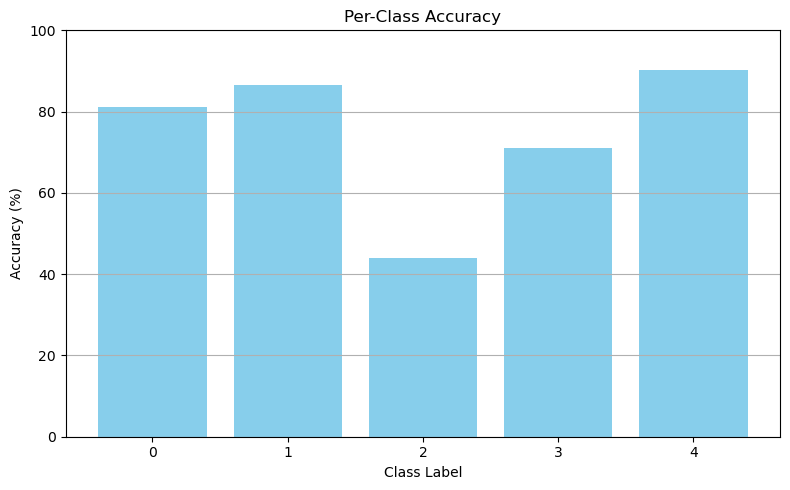

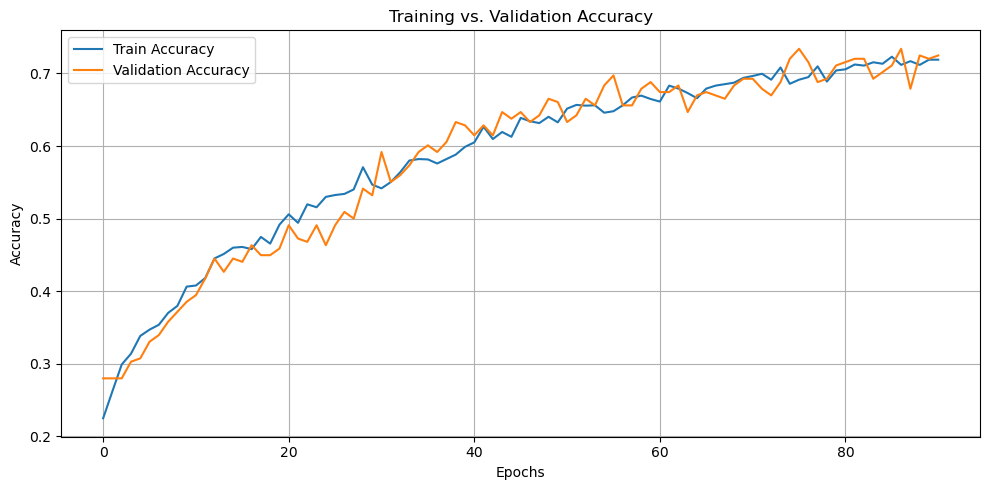

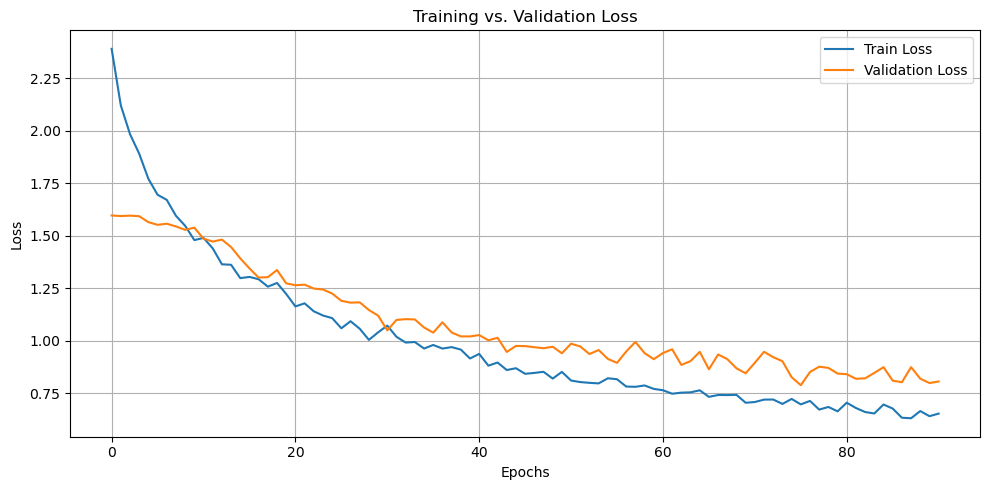

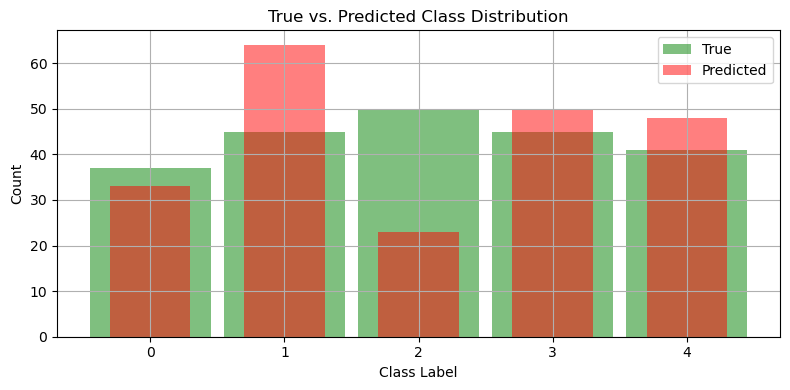

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Create a folder for plots
plot_dir = "plots"
os.makedirs(plot_dir, exist_ok=True)

# === Confusion Matrix Heatmap ===
def plot_confusion_matrix_heatmap(conf_mat):
    plt.figure(figsize=(8, 6))
    labels = [0, 1, 2, 3, 4]
    sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix Heatmap")
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "confusion_matrix_heatmap.png"))
    plt.show()

# === Per-Class Accuracy Bar Chart ===
def plot_per_class_accuracy(conf_mat):
    labels = [0, 1, 2, 3, 4]
    per_class_acc = [100 * conf_mat[i, i] / sum(conf_mat[i]) if sum(conf_mat[i]) > 0 else 0 for i in labels]
    
    plt.figure(figsize=(8, 5))
    plt.bar(labels, per_class_acc, color="skyblue")
    plt.ylim(0, 100)
    plt.xlabel("Class Label")
    plt.ylabel("Accuracy (%)")
    plt.title("Per-Class Accuracy")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "per_class_accuracy.png"))
    plt.show()

# === Training vs Validation Accuracy ===
def plot_training_validation_accuracy(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training vs. Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "training_vs_validation_accuracy.png"))
    plt.show()

# === Training vs Validation Loss ===
def plot_training_validation_loss(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training vs. Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "training_vs_validation_loss.png"))
    plt.show()

# === Prediction vs True Class Distribution ===
def plot_prediction_distribution(y_test, y_pred):
    labels = [0, 1, 2, 3, 4]
    plt.figure(figsize=(8, 4))
    plt.hist(y_test, bins=np.arange(6)-0.5, alpha=0.5, label="True", color='g', rwidth=0.9)
    plt.hist(y_pred, bins=np.arange(6)-0.5, alpha=0.5, label="Predicted", color='r', rwidth=0.6)
    plt.xticks(labels)
    plt.xlabel("Class Label")
    plt.ylabel("Count")
    plt.title("True vs. Predicted Class Distribution")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "true_vs_predicted_distribution.png"))
    plt.show()

# === Run and Save All Plots ===
plot_confusion_matrix_heatmap(conf_mat)
plot_per_class_accuracy(conf_mat)
plot_training_validation_accuracy(history)
plot_training_validation_loss(history)
plot_prediction_distribution(y_test, y_pred)
